# Rep. 3. Checkpoint 3. Limitaciones de Black-Scholes y modelos alternativos

Sara Hernandez y Edgardo

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Simulación Heston
# ---------------------------
def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):

    np.random.seed(seed)
    dt = T / N
    
    S = np.zeros((M, N + 1))
    v = np.zeros((M, N + 1))
    
    S[:,0] = S0
    v[:,0] = v0

    for t in range(1, N+1):
        
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        
        Zs = Z1
        Zv = rho*Z1 + np.sqrt(1-rho**2)*Z2
        
        v_pos = np.maximum(v[:,t-1],0)

        v[:,t] = (
            v_pos
            + kappa*(theta-v_pos)*dt
            + xi*np.sqrt(v_pos*dt)*Zv
        )

        v[:,t] = np.maximum(v[:,t],0)

        S[:,t] = S[:,t-1]*np.exp(
            (mu-0.5*v_pos)*dt
            + np.sqrt(v_pos*dt)*Zs
        )

    return S,v


# ---------------------------
# Simulación GBM (Black-Scholes)
# ---------------------------
def simular_gbm(S0, mu, sigma, T, N, M, seed=42):

    np.random.seed(seed)
    dt = T/N
    
    S = np.zeros((M,N+1))
    S[:,0] = S0
    
    Z = np.random.randn(M,N)
    
    for t in range(1,N+1):
        
        S[:,t] = S[:,t-1]*np.exp(
            (mu-0.5*sigma**2)*dt
            + sigma*np.sqrt(dt)*Z[:,t-1]
        )
        
    return S


# ---------------------------
# Simulación Merton
# ---------------------------
def simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M, seed=42):

    np.random.seed(seed)
    dt = T/N
    
    S = np.zeros((M,N+1))
    S[:,0] = S0
    
    for t in range(1,N+1):

        Z = np.random.randn(M)

        gbm = (
            (mu-0.5*sigma**2)*dt
            + sigma*np.sqrt(dt)*Z
        )

        n_saltos = np.random.poisson(lam*dt, M)

        log_salto = np.array([
            np.sum(np.random.normal(mu_j,sigma_j,n)) if n>0 else 0
            for n in n_saltos
        ])

        S[:,t] = S[:,t-1]*np.exp(gbm+log_salto)

    return S

## Heston

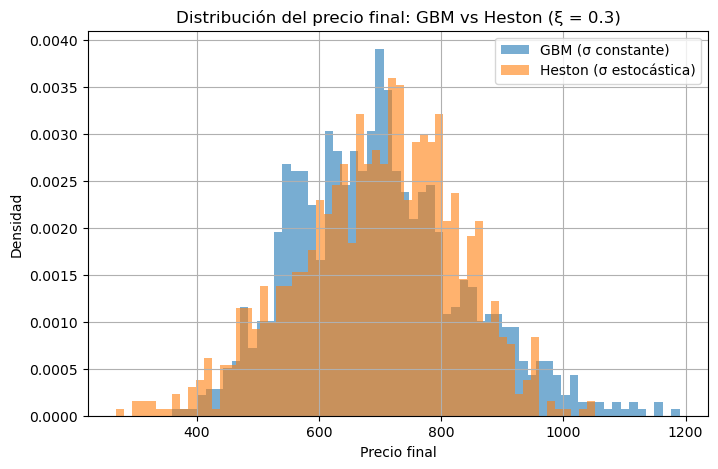

In [2]:
# -------------------
# Parámetros base
# -------------------

S0 = 669.03
v0 = 0.04
mu = 0.042

kappa = 2.0
theta = 0.04
xi = 0.3
rho = -0.7

sigma_const = 0.20

T = 1
N = 252
M = 1000


# -------------------
# Simulaciones
# -------------------

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

S_gbm = simular_gbm(S0, mu, sigma_const, T, N, M)


# -------------------
# Gráfica comparación
# -------------------

plt.figure(figsize=(8,5))

plt.hist(S_gbm[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="GBM (σ constante)")

plt.hist(S_heston[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="Heston (σ estocástica)")

plt.title("Distribución del precio final: GBM vs Heston (ξ = 0.3)")
plt.xlabel("Precio final")
plt.ylabel("Densidad")

plt.legend()
plt.grid(True)

plt.show()

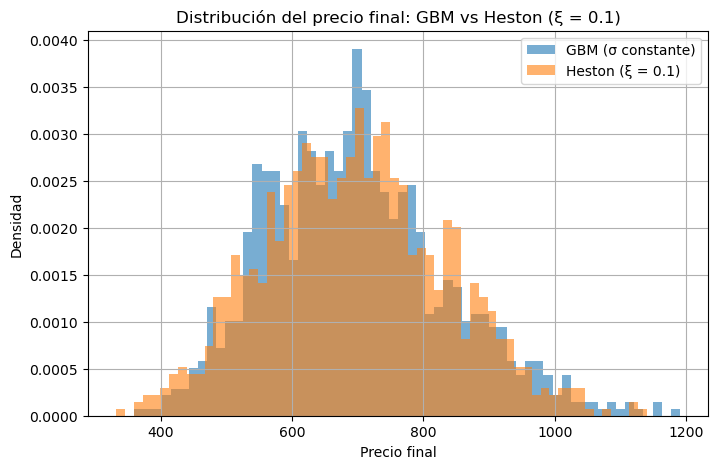

In [3]:
# -------------------
# Heston con xi = 0.1
# -------------------

xi = 0.1

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)


plt.figure(figsize=(8,5))

plt.hist(S_gbm[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="GBM (σ constante)")

plt.hist(S_heston[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="Heston (ξ = 0.1)")

plt.title("Distribución del precio final: GBM vs Heston (ξ = 0.1)")
plt.xlabel("Precio final")
plt.ylabel("Densidad")

plt.legend()
plt.grid(True)

plt.show()



In [4]:
print("Media:", np.mean(S_heston[:,-1]))
print("Desviación estándar:", np.std(S_heston[:,-1]))
print("Mínimo:", np.min(S_heston[:,-1]))
print("Máximo:", np.max(S_heston[:,-1]))

Media: 696.1190770608586
Desviación estándar: 137.26555729224432
Mínimo: 332.05947233606645
Máximo: 1140.0323464393841


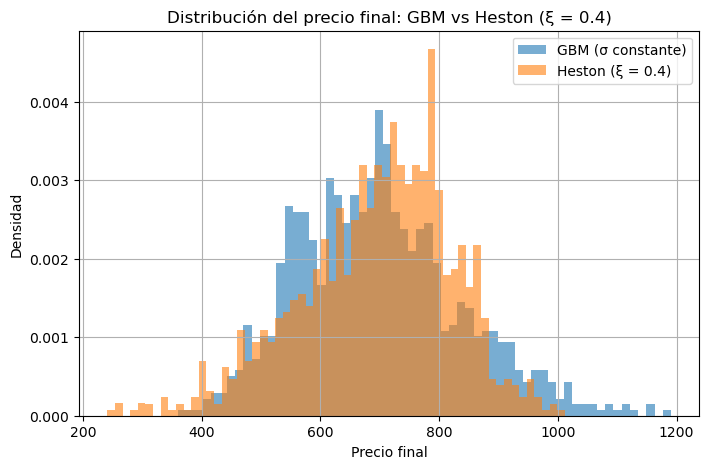

In [5]:
# -------------------
# Heston con xi = 0.4
# -------------------

xi = 0.4

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

plt.figure(figsize=(8,5))

plt.hist(S_gbm[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="GBM (σ constante)")

plt.hist(S_heston[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="Heston (ξ = 0.4)")

plt.title("Distribución del precio final: GBM vs Heston (ξ = 0.4)")
plt.xlabel("Precio final")
plt.ylabel("Densidad")

plt.legend()
plt.grid(True)

plt.show()

In [6]:
print("Media:", np.mean(S_heston[:,-1]))
print("Desviación estándar:", np.std(S_heston[:,-1]))
print("Mínimo:", np.min(S_heston[:,-1]))
print("Máximo:", np.max(S_heston[:,-1]))

Media: 694.2104479850889
Desviación estándar: 128.63716318489642
Mínimo: 240.9401286628839
Máximo: 1011.9841500379757


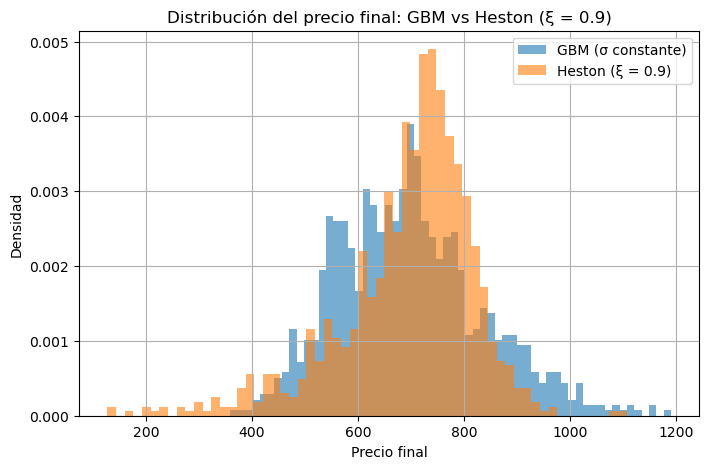

In [7]:
# -------------------
# Heston con xi = 0.9
# -------------------

xi = 0.9

S_heston, v_heston = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

plt.figure(figsize=(8,5))

plt.hist(S_gbm[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="GBM (σ constante)")

plt.hist(S_heston[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="Heston (ξ = 0.9)")

plt.title("Distribución del precio final: GBM vs Heston (ξ = 0.9)")
plt.xlabel("Precio final")
plt.ylabel("Densidad")

plt.legend()
plt.grid(True)

plt.show()

In [8]:
print("Media:", np.mean(S_heston[:,-1]))
print("Desviación estándar:", np.std(S_heston[:,-1]))
print("Mínimo:", np.min(S_heston[:,-1]))
print("Máximo:", np.max(S_heston[:,-1]))

Media: 693.6915388405172
Desviación estándar: 126.80719907345976
Mínimo: 127.2694709337741
Máximo: 1106.9805523788482


## Merton

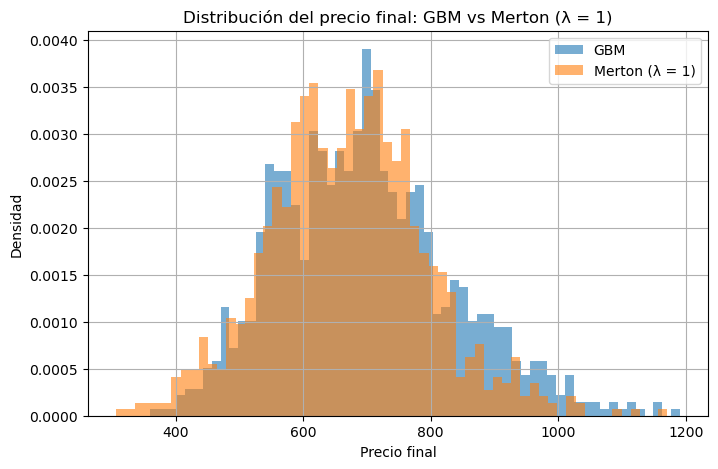

In [9]:
# -------------------
# Parámetros Merton
# -------------------

lam = 1      # saltos por año
mu_j = -0.05
sigma_j = 0.10

sigma = 0.15


# -------------------
# Simulación
# -------------------

S_merton = simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M)


# -------------------
# Gráfica
# -------------------

plt.figure(figsize=(8,5))

plt.hist(S_gbm[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="GBM")

plt.hist(S_merton[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="Merton (λ = 1)")

plt.title("Distribución del precio final: GBM vs Merton (λ = 1)")
plt.xlabel("Precio final")
plt.ylabel("Densidad")

plt.legend()
plt.grid(True)

plt.show()

In [10]:
print("Media:", np.mean(S_merton[:,-1]))
print("Desviación estándar:", np.std(S_merton[:,-1]))
print("Mínimo:", np.min(S_merton[:,-1]))
print("Máximo:", np.max(S_merton[:,-1]))

Media: 669.2810988356129
Desviación estándar: 123.22106255418274
Mínimo: 306.6455959700708
Máximo: 1171.1512976152678


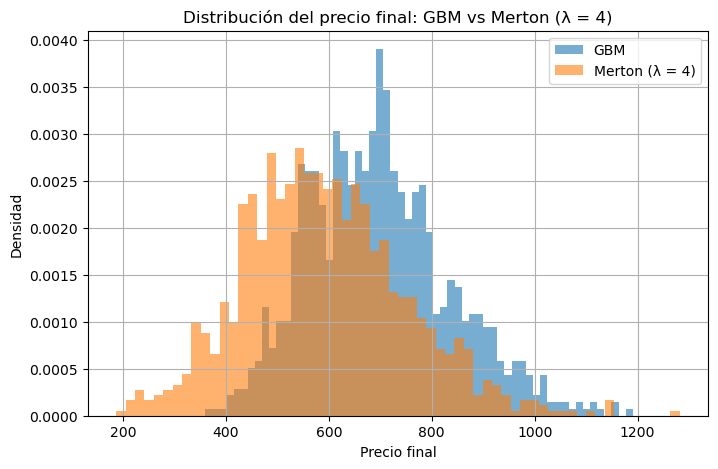

In [11]:
# -------------------
# Merton con lambda = 4
# -------------------

lam = 4

S_merton = simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M)

plt.figure(figsize=(8,5))

plt.hist(S_gbm[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="GBM")

plt.hist(S_merton[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="Merton (λ = 4)")

plt.title("Distribución del precio final: GBM vs Merton (λ = 4)")
plt.xlabel("Precio final")
plt.ylabel("Densidad")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
print("Media:", np.mean(S_merton[:,-1]))
print("Desviación estándar:", np.std(S_merton[:,-1]))
print("Mínimo:", np.min(S_merton[:,-1]))
print("Máximo:", np.max(S_merton[:,-1]))

Media: 590.838397324837
Desviación estándar: 157.22584554925274
Mínimo: 186.96561937077155
Máximo: 1281.9443084364264


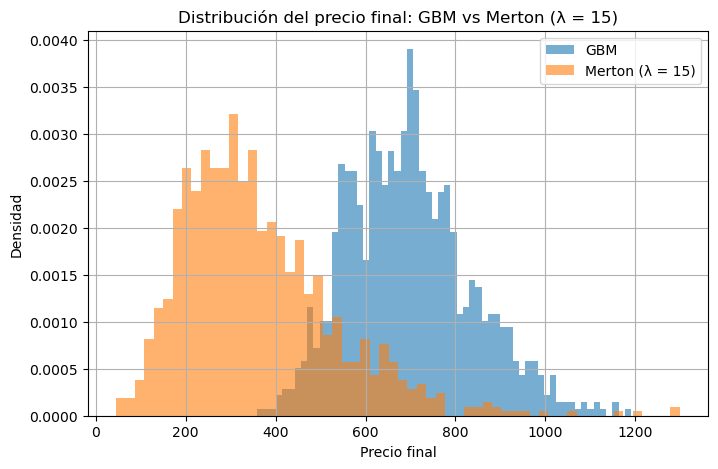

In [13]:
# -------------------
# Merton con lambda = 15
# -------------------

lam = 15

S_merton = simular_merton(S0, mu, sigma, lam, mu_j, sigma_j, T, N, M)

plt.figure(figsize=(8,5))

plt.hist(S_gbm[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="GBM")

plt.hist(S_merton[:,-1],
         bins=60,
         density=True,
         alpha=0.6,
         label="Merton (λ = 15)")

plt.title("Distribución del precio final: GBM vs Merton (λ = 15)")
plt.xlabel("Precio final")
plt.ylabel("Densidad")

plt.legend()
plt.grid(True)

plt.show()

In [14]:
print("Media:", np.mean(S_merton[:,-1]))
print("Desviación estándar:", np.std(S_merton[:,-1]))
print("Mínimo:", np.min(S_merton[:,-1]))
print("Máximo:", np.max(S_merton[:,-1]))

Media: 360.04771301776145
Desviación estándar: 169.98548148211225
Mínimo: 45.48522891452278
Máximo: 1299.0609396021332


# Preguntas

1. **En la simulación de Heston, ¿qué efecto tiene aumentar ξ (vol of vol) sobre la distribución del precio final? ¿Y sobre el skew?**

Al aumentar ξ, la volatilidad fluctúa más en el tiempo, por lo que la distribución del precio final se vuelve más dispersa y aparecen valores más extremos. La media casi no cambia, pero aumenta la variabilidad. Además, se acentúa el skew negativo, porque cuando el precio cae la volatilidad tiende a subir (ρ < 0).

2. **En la simulación de Merton, cambia λ de 4 a 10. ¿Cómo cambian las trayectorias? ¿Y la distribución final?**

Cuando λ aumenta, ocurren más saltos por año. Las trayectorias muestran más caídas o movimientos bruscos en lugar de movimientos suaves. La distribución final se vuelve más dispersa y con cola izquierda más gruesa, y el precio promedio tiende a bajar porque los saltos suelen ser negativos.

3. **Si el mercado tiene fat tails y BS los ignora, ¿en qué dirección estará sesgado el precio BS de un put muy OTM?**

El precio estará subestimado. Black-Scholes asume colas delgadas y subestima la probabilidad de caídas extremas. Como los puts muy OTM pagan en escenarios de crash, el modelo termina valuándolos demasiado baratos.

4. **Merton asume que los saltos tienen λ constante. ¿Qué limitación tiene eso?**

En la realidad, la frecuencia de saltos cambia con el tiempo. Durante crisis o noticias importantes los saltos ocurren mucho más seguido. Suponer λ constante no captura bien esos periodos de estrés del mercado.

5. **¿Por qué BS sigue siendo el estándar de cotización?**

Porque es simple y universal. Aunque Heston y Merton son más realistas, tienen más parámetros y son más complejos. En el mercado las opciones se cotizan en volatilidad implícita, y Black-Scholes funciona como el lenguaje común para convertir entre precio y volatilidad.